## Imports

In [1]:
import scipy
from amocatlas import read
from amoc_analysis import data
from amoc_analysis.spectra_filtering.data_io import fill_gaps
import matplotlib.pyplot as plt

%load_ext autoreload

## Read MOVE data

In [2]:
# Read dataset
ds = read.move()   # 16N (also: read.osnap(), read.move(),read.samba(), read.fw2015(), ...)
moc_raw    = ds.MOC

# Fill missing values
moc_filled = fill_gaps(values=moc_raw, method='linear')

# Time between data points
dt_days = 2.0   # 48 h = 2 days

# moc_raw

Loading 1 MOVE 16°N dataset(s):
  0. OS_MOVE_20000206-20221014_DPR_VOLUMETRANSPORT.nc: MOVE transport time series



## Raw and filtered timeseries

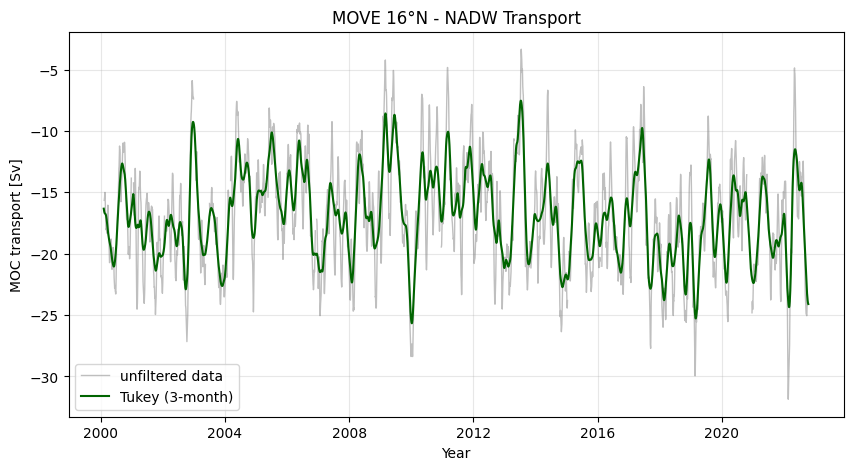

In [3]:
from amoc_analysis.spectra_filtering.filters import tukey_lowpass

# Tukey low-pass filter
window_size = round((365/12 * 3) / dt_days)     # 3-month window
moc_filtered = tukey_lowpass(values=moc_filled, window=window_size)

# Plot unfilled and filtered timeseries
fig = plt.figure(figsize=(10,5))
plt.plot(ds.TIME, moc_raw, lw=1, c='grey', alpha=0.5, label='unfiltered data')
plt.plot(ds.TIME, moc_filtered, c='darkgreen', label='Tukey (3-month)')

# Figure settings
plt.legend()
plt.title('MOVE 16°N - NADW Transport')
plt.xlabel('Year')
plt.ylabel('MOC transport [Sv]')
plt.grid(alpha=0.3)

# Save and show
plt.savefig('../plots/timeseries.png', bbox_inches='tight')
plt.savefig('../plots/timeseries.pdf', bbox_inches='tight')
plt.show()

## Basic statistics

In [4]:
from amoc_analysis.spectra_filtering.analysis import summary_stats

stats = summary_stats(moc_raw)
stats

{'n': 4164,
 'n_missing': 180,
 'mean': np.float64(-16.920485508780807),
 'std': np.float64(4.486071942040062),
 'median': np.float64(-16.97935440058517),
 'min': np.float64(-31.85568629885044),
 'max': np.float64(-3.339813335100806),
 'range': np.float64(28.515872963749633)}

## MOC transport histogram

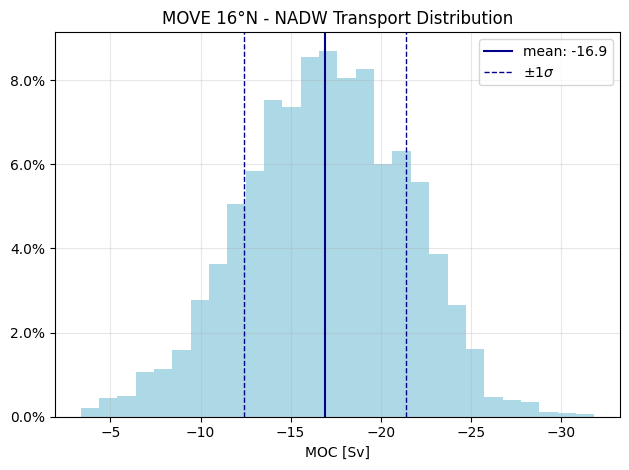

In [5]:
from matplotlib.ticker import PercentFormatter

# Make figure
fig, ax = plt.subplots(tight_layout=True)

# Plot histogram
plt.hist(moc_raw, bins=int(stats['range']), density=True, color='lightblue')

# Plot mean
plt.axvline(x=stats['mean'], c='darkblue', label=f'mean: {stats['mean']:.1f}')

# Plot standard deviation
plt.axvline(x=stats['mean']+stats['std'], c='darkblue', ls='dashed', lw=1, label=r'$\pm 1 \sigma$')
plt.axvline(x=stats['mean']-stats['std'], c='darkblue', ls='dashed', lw=1)

# Figure settings
plt.title('MOVE 16°N - NADW Transport Distribution')
plt.xlabel('MOC [Sv]')
plt.grid(alpha=0.3)
plt.legend()

# Invert x-axis to show increasing southward flow
ax.xaxis.set_inverted(True)

# Format y-axis ticks as percentages
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))

# Save and show fig
plt.savefig('../plots/hist.pdf', bbox_inches='tight')
plt.savefig('../plots/hist.png', bbox_inches='tight')
plt.show()

## Nyquist frequency and periodogram

Nyquist frequency f_N = 0.25 cycles per day (cpd)
Parseval ratio = 0.9871017039539788


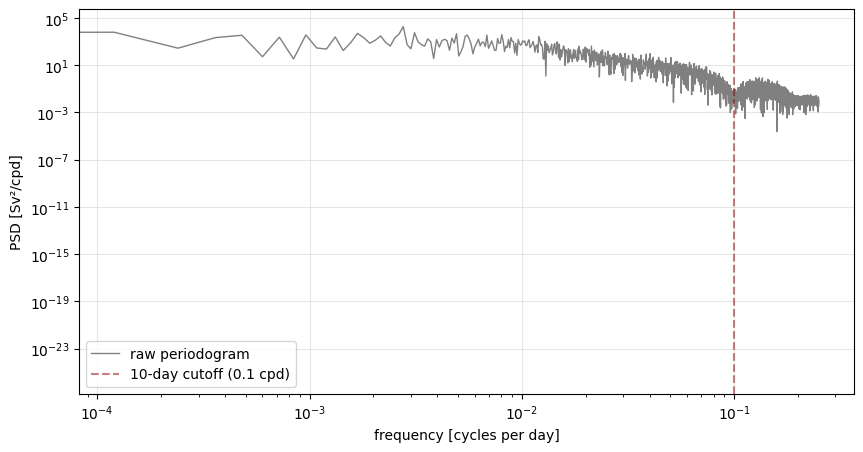

In [6]:
%autoreload
from amoc_analysis.spectra_filtering.filters import nyquist_frequency
from amoc_analysis.spectra_filtering.spectra import raw_periodogram

n = stats['n']

# Nyquist frequency
f_N = nyquist_frequency(dt_days) # cycles per day (cpd)
print(f'Nyquist frequency f_N = {f_N} cycles per day (cpd)')

# Compute periodogram
f_period, psd_period = raw_periodogram(x=moc_filled, dt_days=dt_days, window='boxcar')

# Make figure
fig = plt.figure(figsize=(10,5))

# Plot spectrum
plt.loglog(f_period, psd_period, lw=1, c='grey', alpha=1, label='raw periodogram')

# Plot 10 day cutoff
plt.axvline(x=0.1, c='darkred', ls='dashed', alpha=0.5, label='10-day cutoff (0.1 cpd)')

# Figure settings
plt.grid(alpha=0.3)
plt.legend()
plt.ylabel('PSD [Sv²/cpd]')
plt.xlabel('frequency [cycles per day]')

plt.show()

- Nyquist frequency of 0.25 cpd -> only frequencies lower than one full oscillation in 4 days are represented

## Welch spectrum

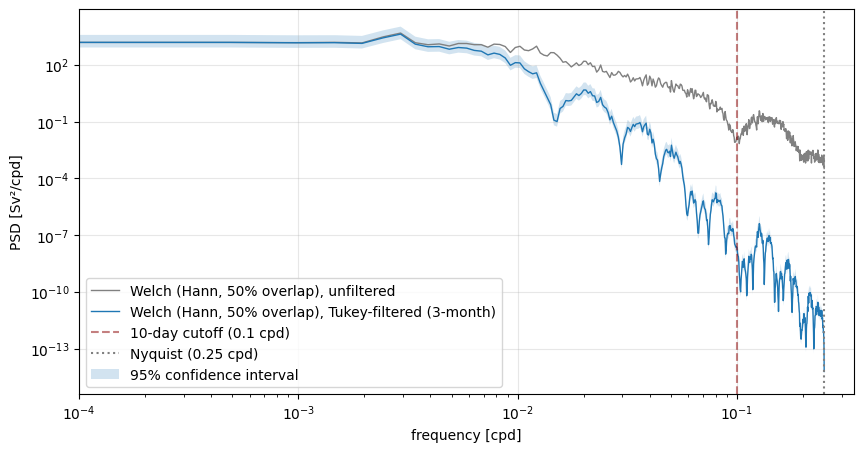

In [7]:
%autoreload
from amoc_analysis.spectra_filtering.spectra import welch_psd
from scipy.stats import chi2
from scipy.signal import detrend

# Detrend filtered data
moc_filtered_detrended = detrend(moc_filtered, type='linear') 
# Detrend filled data
moc_raw_detrended = detrend(moc_filled, type='linear') 

# Specify segment length
segment_length=1024

# Compute Welch spectrum of unfiltered data
f_welch1, psd_welch1 = welch_psd(
    # x=moc_filled, 
    x=moc_raw_detrended, 
    dt_days=dt_days, 
    window='hann', 
    segment_length=segment_length)

# Compute Welch spectrum of filtered data
f_welch, psd_welch = welch_psd(
    # x=moc_filtered, 
    x=moc_filtered_detrended, 
    dt_days=dt_days, 
    window='hann', 
    segment_length=segment_length)

# Compute confidence intervals
noverlap = int(segment_length * 0.5)
step = segment_length - noverlap
K = (stats['n'] - noverlap) // step           # number of segments
dof = 2 * K     # degrees of freedom
lo = dof / chi2.ppf(0.975, dof)
hi = dof / chi2.ppf(0.025, dof)


# Make figure
fig = plt.figure(figsize=(10,5))

# Plot periodogram
# plt.loglog(f_period, psd_period, lw=1, c='grey', alpha=0.4, label='periodogram')
# Plot Welch spectrum
plt.loglog(f_welch1, psd_welch1, lw=1, c='grey', alpha=1, label='Welch (Hann, 50% overlap), unfiltered')
plt.loglog(f_welch, psd_welch, lw=1, c='tab:blue', alpha=1, label='Welch (Hann, 50% overlap), Tukey-filtered (3-month)')
# Highlight 10 day cutoff
plt.axvline(x=0.1, c='darkred', ls='dashed', alpha=0.5, label='10-day cutoff (0.1 cpd)')
# Highlight Nyquist frequency
plt.axvline(x=f_N, c='grey', ls='dotted', alpha=1, label='Nyquist (0.25 cpd)')

# PLot confidence interval around Welch
plt.fill_between(f_welch, psd_welch*lo, psd_welch*hi, alpha=0.2, label='95% confidence interval')

# Fig settings
plt.grid(alpha=0.3)
plt.legend()
plt.ylabel('PSD [Sv²/cpd]')
plt.xlabel('frequency [cpd]')
plt.xlim(left=1e-4)

# Save and show
plt.savefig('../plots/welch.png', bbox_inches='tight')
plt.savefig('../plots/welch.pdf', bbox_inches='tight')
plt.show()

- peak at $10^{-2.7}$ cpd -> annual cycle -> seasonal cycle of AMOC
- peak around $10^{-1.9}$ cpd -> ca. 5 cycles per year -> ?

### Parseval check

In [8]:
%autoreload
from amoc_analysis.spectra_filtering.spectra import parseval_ratio

ratio = parseval_ratio(x=moc_filtered, freq=f_welch, psd=psd_welch)
# ratio = parseval_ratio(x=mscaling='density'oc_filled, freq=f_welch1, psd=psd_welch1)
print(f'Parseval ratio = {ratio}')

Parseval ratio = 0.8920207105117529
